imports 👇

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import seaborn as sb

preprocessing 👇

In [2]:
data=pd.read_csv('Energy_consumption_dataset.csv')
data

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,1,0,Saturday,No,25.139433,43.431581,1565.693999,5,On,Off,2.774699,75.364373
1,1,1,Saturday,No,27.731651,54.225919,1411.064918,1,On,On,21.831384,83.401855
2,1,2,Saturday,No,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,78.270888
3,1,3,Saturday,No,20.080469,50.371637,1452.316318,1,Off,On,8.623447,56.519850
4,1,4,Saturday,No,23.097359,51.401421,1094.130359,9,On,Off,3.071969,70.811732
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,12,6,Sunday,Yes,26.338718,52.580000,1563.567259,7,On,On,20.591717,70.270344
4996,12,17,Monday,No,20.007565,42.765607,1999.982252,5,Off,On,7.536319,73.943071
4997,12,13,Thursday,Yes,26.226253,30.015975,1999.982252,5,Off,On,28.162193,85.784613
4998,12,8,Saturday,Yes,24.673206,50.223939,1240.811298,2,On,On,20.918483,63.784001


In [3]:
data.head(15)

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,1,0,Saturday,No,25.139433,43.431581,1565.693999,5,On,Off,2.774699,75.364373
1,1,1,Saturday,No,27.731651,54.225919,1411.064918,1,On,On,21.831384,83.401855
2,1,2,Saturday,No,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,78.270888
3,1,3,Saturday,No,20.080469,50.371637,1452.316318,1,Off,On,8.623447,56.519850
4,1,4,Saturday,No,23.097359,51.401421,1094.130359,9,On,Off,3.071969,70.811732
5,1,5,Saturday,Yes,29.576037,36.824263,1871.709180,6,Off,Off,17.626690,84.321885
6,1,6,Saturday,Yes,25.131167,35.709622,1607.001228,6,On,Off,24.264702,76.165791
7,1,7,Saturday,Yes,23.182844,31.679920,1633.955330,8,Off,Off,27.517099,74.131906
8,1,8,Saturday,No,25.391999,46.399364,1240.309224,6,On,Off,2.307595,78.206236
9,1,9,Saturday,No,22.212549,32.418464,1705.420336,1,On,Off,29.140071,77.992214


In [4]:
data.tail(15)

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
4985,12,22,Wednesday,Yes,23.192571,58.465341,1430.805459,3,On,Off,17.900462,76.394479
4986,12,14,Saturday,Yes,24.550482,49.576684,1088.182555,7,Off,On,22.768362,78.813422
4987,12,15,Wednesday,No,27.019655,30.015975,1919.675356,4,Off,Off,29.058316,73.461991
4988,12,4,Monday,No,20.007565,32.329919,1523.599469,6,On,Off,14.530702,59.523666
4989,12,1,Friday,Yes,23.852533,31.832450,1550.373230,9,On,On,6.633631,86.040988
4990,12,17,Friday,No,26.656032,50.266501,1686.134682,3,On,Off,13.944694,83.994154
4991,12,7,Monday,No,22.075505,50.440339,1776.059835,7,Off,On,2.743279,89.783736
4992,12,18,Friday,No,22.812709,45.675570,1491.654728,3,Off,On,25.964014,74.246762
4993,12,18,Sunday,No,24.932388,57.466207,1595.115001,7,Off,On,29.965327,80.757956
4994,12,1,Saturday,Yes,26.298721,44.554798,1654.879176,6,Off,On,21.314698,64.544315


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Month              5000 non-null   int64  
 1   Hour               5000 non-null   int64  
 2   DayOfWeek          5000 non-null   object 
 3   Holiday            5000 non-null   object 
 4   Temperature        5000 non-null   float64
 5   Humidity           5000 non-null   float64
 6   SquareFootage      5000 non-null   float64
 7   Occupancy          5000 non-null   int64  
 8   HVACUsage          5000 non-null   object 
 9   LightingUsage      5000 non-null   object 
 10  RenewableEnergy    5000 non-null   float64
 11  EnergyConsumption  5000 non-null   float64
dtypes: float64(5), int64(3), object(4)
memory usage: 468.9+ KB


In [6]:
data.describe()

,Month,Hour,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.251200,11.556000,24.946823,45.478146,1507.403201,4.576000,15.201195,76.794919
std,3.588687,6.888306,3.041678,8.972690,293.147209,2.906185,9.157038,9.231573
min,1.000000,0.000000,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,3.000000,6.000000,22.453790,38.111104,1253.906598,2.000000,7.477928,70.419588
50%,6.000000,11.000000,24.831846,45.793124,1513.581105,5.000000,15.343830,76.696267
75%,9.000000,18.000000,27.427281,52.696651,1754.846457,7.000000,22.889997,83.246274
max,12.000000,23.000000,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [7]:
data.isnull().sum()

Month                0
Hour                 0
DayOfWeek            0
Holiday              0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
EnergyConsumption    0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.drop(['Month','DayOfWeek','Holiday'],axis=1,inplace=True)
data

,Hour,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,0,25.139433,43.431581,1565.693999,5,On,Off,2.774699,75.364373
1,1,27.731651,54.225919,1411.064918,1,On,On,21.831384,83.401855
2,2,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,78.270888
3,3,20.080469,50.371637,1452.316318,1,Off,On,8.623447,56.519850
4,4,23.097359,51.401421,1094.130359,9,On,Off,3.071969,70.811732
...,...,...,...,...,...,...,...,...,...
4995,6,26.338718,52.580000,1563.567259,7,On,On,20.591717,70.270344
4996,17,20.007565,42.765607,1999.982252,5,Off,On,7.536319,73.943071
4997,13,26.226253,30.015975,1999.982252,5,Off,On,28.162193,85.784613
4998,8,24.673206,50.223939,1240.811298,2,On,On,20.918483,63.784001


In [10]:
data["HVACUsage"].value_counts()

HVACUsage
On     2500
Off    2500
Name: count, dtype: int64

In [11]:
data["LightingUsage"].value_counts()

LightingUsage
Off    2543
On     2457
Name: count, dtype: int64

In [12]:
le_hvac=LabelEncoder()
le_light=LabelEncoder()
data["HVACUsage"]=le_hvac.fit_transform(data["HVACUsage"])
data["LightingUsage"]=le_light.fit_transform(data["LightingUsage"])

In [13]:
data

,Hour,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,0,25.139433,43.431581,1565.693999,5,1,0,2.774699,75.364373
1,1,27.731651,54.225919,1411.064918,1,1,1,21.831384,83.401855
2,2,28.704277,58.907658,1755.715009,2,0,0,6.764672,78.270888
3,3,20.080469,50.371637,1452.316318,1,0,1,8.623447,56.519850
4,4,23.097359,51.401421,1094.130359,9,1,0,3.071969,70.811732
...,...,...,...,...,...,...,...,...,...
4995,6,26.338718,52.580000,1563.567259,7,1,1,20.591717,70.270344
4996,17,20.007565,42.765607,1999.982252,5,0,1,7.536319,73.943071
4997,13,26.226253,30.015975,1999.982252,5,0,1,28.162193,85.784613
4998,8,24.673206,50.223939,1240.811298,2,1,1,20.918483,63.784001


ploting 👇

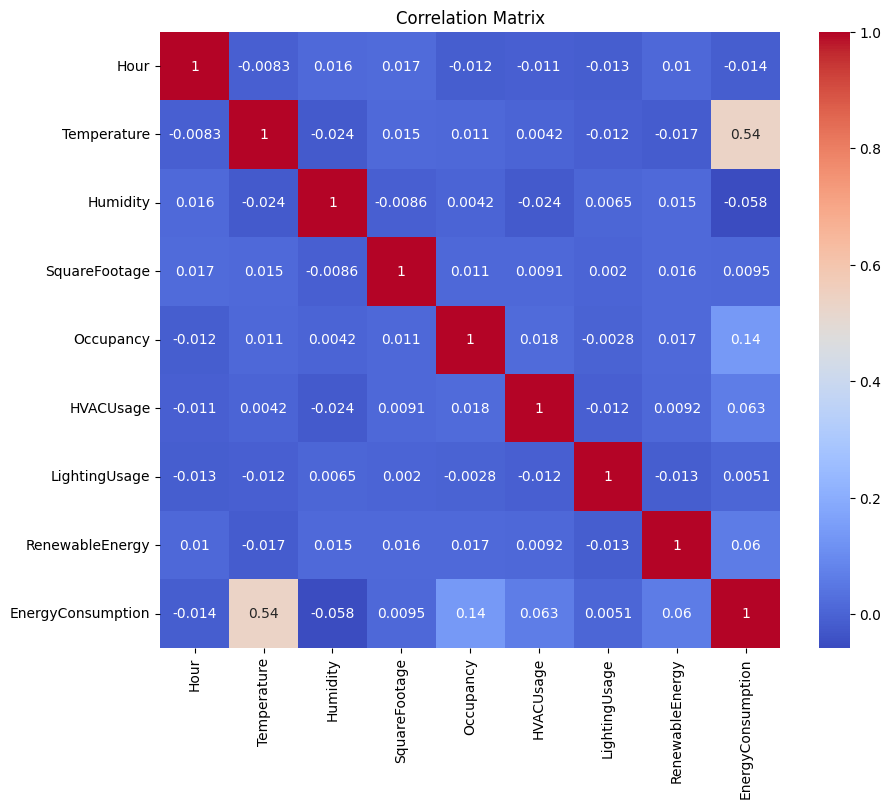

In [14]:
plt.figure(figsize=(10,8))
sb.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

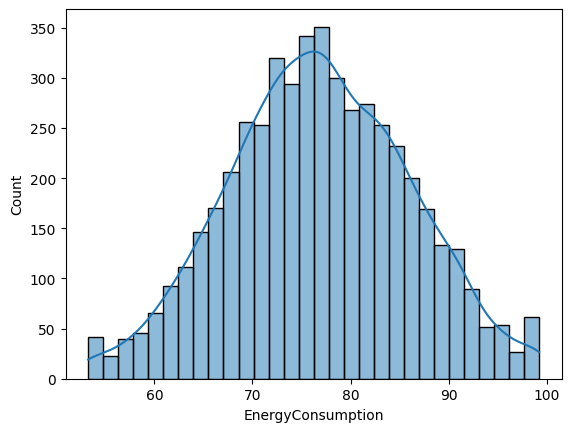

In [15]:
sb.histplot(data["EnergyConsumption"], bins=30, kde=True)
plt.show()

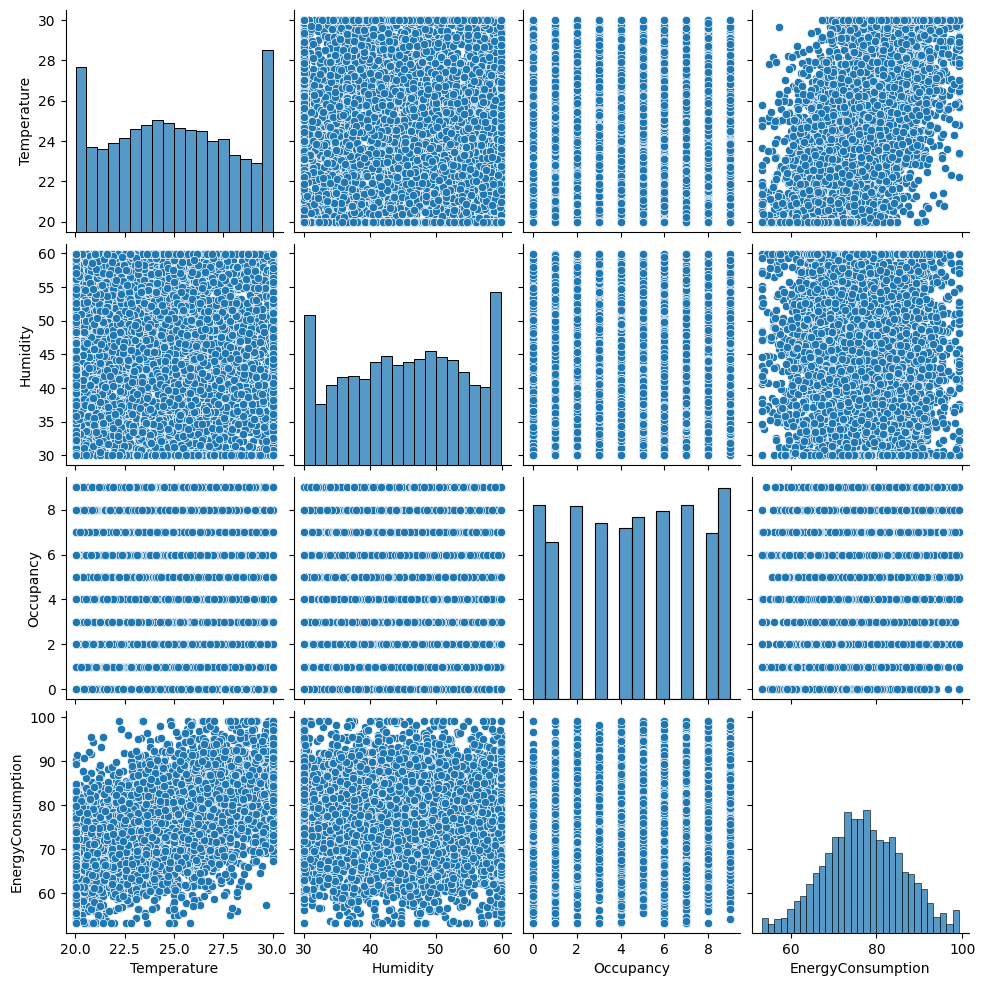

In [16]:
sb.pairplot(data[["Temperature","Humidity","Occupancy","EnergyConsumption"]])
plt.show()

seprating and scaling 👇

In [17]:
data.head(5)

,Hour,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,0,25.139433,43.431581,1565.693999,5,1,0,2.774699,75.364373
1,1,27.731651,54.225919,1411.064918,1,1,1,21.831384,83.401855
2,2,28.704277,58.907658,1755.715009,2,0,0,6.764672,78.270888
3,3,20.080469,50.371637,1452.316318,1,0,1,8.623447,56.519850
4,4,23.097359,51.401421,1094.130359,9,1,0,3.071969,70.811732


In [18]:
x=data.iloc[:,:-1]
x

,Hour,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy
0,0,25.139433,43.431581,1565.693999,5,1,0,2.774699
1,1,27.731651,54.225919,1411.064918,1,1,1,21.831384
2,2,28.704277,58.907658,1755.715009,2,0,0,6.764672
3,3,20.080469,50.371637,1452.316318,1,0,1,8.623447
4,4,23.097359,51.401421,1094.130359,9,1,0,3.071969
...,...,...,...,...,...,...,...,...
4995,6,26.338718,52.580000,1563.567259,7,1,1,20.591717
4996,17,20.007565,42.765607,1999.982252,5,0,1,7.536319
4997,13,26.226253,30.015975,1999.982252,5,0,1,28.162193
4998,8,24.673206,50.223939,1240.811298,2,1,1,20.918483


In [19]:
x=scale(x)
x

array([[-1.67779371,  0.0633301 , -0.22811101, ...,  1.        ,
        -0.98294541, -1.35717895],
       [-1.53260561,  0.91564804,  0.97503057, ...,  1.        ,
         1.0173505 ,  0.72412639],
       [-1.38741751,  1.23544644,  1.49685927, ..., -1.        ,
        -0.98294541, -0.92140789],
       ...,
       [ 0.20965162,  0.42067502, -1.72342036, ..., -1.        ,
         1.0173505 ,  1.41555541],
       [-0.51628889, -0.08996499,  0.52896811, ...,  1.        ,
         1.0173505 ,  0.62442243],
       [-1.53260561,  0.28146783, -0.41009834, ..., -1.        ,
        -0.98294541, -0.75000264]], shape=(5000, 8))

In [20]:
y=data['EnergyConsumption']
y

0       75.364373
1       83.401855
2       78.270888
3       56.519850
4       70.811732
          ...    
4995    70.270344
4996    73.943071
4997    85.784613
4998    63.784001
4999    53.263278
Name: EnergyConsumption, Length: 5000, dtype: float64

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

creating models and evaluating 👇

In [22]:
model=LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred=model.predict(x_test)

In [24]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("mse:",mse)
print("mae:",mae)

mse: 62.434914301760706
mae: 6.255110270917598


In [25]:
rf=RandomForestRegressor(
    n_estimators=600,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(x_train,y_train)

,n_estimators,600
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
y_pred=rf.predict(x_test)
print("mse:",mean_squared_error(y_test, y_pred))
print("mae:",mean_absolute_error(y_test, y_pred))

mse: 65.80107750125423
mae: 6.418069002075378


In [27]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
y_pred=xgb_model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("mse:",mse)
print("mae:",mae)

mse: 68.58739378444652
mae: 6.582291571884448


testing 👇

In [29]:
one_row=data.iloc[[10]].drop("EnergyConsumption",axis=1)
one_row

,Hour,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy
10,10,28.064814,36.451472,1341.467129,2,0,0,0.352238


In [30]:
one_row_scaled=(one_row-data['EnergyConsumption'].mean())/data['EnergyConsumption'].std()
one_row

,Hour,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy
10,10,28.064814,36.451472,1341.467129,2,0,0,0.352238


In [31]:
prediction = model.predict(one_row_scaled)
print("predicted value:",prediction[0])
print("actual value:",data.iloc[10]["EnergyConsumption"])

predicted value: 57.34853106869038
actual value: 82.27443448386548


C:\Users\ASUS FX506HE\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


creating gui 👇

In [32]:
x=data.drop("EnergyConsumption",axis=1)
mean=x.mean()
std=x.std()

In [33]:
import tkinter as tk
def predict_energy():
    try:
        values=[
            float(entry_hour.get()),
            float(entry_temp.get()),
            float(entry_humidity.get()),
            float(entry_square.get()),
            float(entry_occupancy.get()),
            float(entry_hvac.get()),
            float(entry_lighting.get()),
            float(entry_renewable.get())
        ]
        input_df=pd.DataFrame([values], columns=x.columns)
        input_scaled=(input_df-mean)/std
        prediction=model.predict(input_scaled)
        result_label.config(text=f"predicted energy: {prediction[0]:.2f}")
    except:
        result_label.config(text="invalid input!")

root=tk.Tk()
root.title("energy predictor")
root.geometry("400x520")

labels=[
    "Hour",
    "Temperature",
    "Humidity",
    "SquareFootage",
    "Occupancy",
    "HVACUsage",
    "LightingUsage",
    "RenewableEnergy"
]

entries=[]

for label in labels:
    tk.Label(root, text=label).pack()
    entry=tk.Entry(root)
    entry.pack()
    entries.append(entry)

(entry_hour,
 entry_temp,
 entry_humidity,
 entry_square,
 entry_occupancy,
 entry_hvac,
 entry_lighting,
 entry_renewable) = entries

tk.Button(root,text="predict",command=predict_energy).pack(pady=10)

result_label=tk.Label(root,text="",font=("Arial", 12))
result_label.pack()

root.mainloop()